### Importando Bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

### Carregando Dados

In [2]:
df_vendas = pd.read_csv('../data/processed/vendas_2023_2024_processed.csv')
df_vendas['sale_date'] = pd.to_datetime(df_vendas['sale_date'])

In [3]:
data_min = df_vendas['sale_date'].min()
data_max = df_vendas['sale_date'].max()

calendario = pd.DataFrame({
    'data': pd.date_range(start=data_min, end=data_max, freq='D')
})

In [4]:
vendas_diarias = df_vendas.groupby('sale_date')['total'].sum().reset_index()
vendas_diarias.columns = ['data', 'total_vendas']
vendas_diarias.head(5)

,data,total_vendas
0,2023-01-01,4207939.25
1,2023-01-02,5102799.80
2,2023-01-03,8299127.05
3,2023-01-04,4707759.40
4,2023-01-05,5525706.90


In [5]:
df_cal = calendario.merge(vendas_diarias, on='data', how='left')
df_cal['total_vendas'] = df_cal['total_vendas'].fillna(0)

dias_pt = {
    0: 'Segunda-feira',
    1: 'Terça-feira',
    2: 'Quarta-feira',
    3: 'Quinta-feira',
    4: 'Sexta-feira',
    5: 'Sábado',
    6: 'Domingo'
}
df_cal['num_dia'] = df_cal['data'].dt.dayofweek
df_cal['dia_semana'] = df_cal['num_dia'].map(dias_pt)

#### Média por dia da semana

In [6]:
media_com_zeros = df_cal.groupby(['num_dia', 'dia_semana'])['total_vendas'].mean().reset_index()
media_com_zeros.columns = ['num_dia', 'dia_semana', 'media_com_zeros']
media_com_zeros = media_com_zeros.sort_values('num_dia')

# Sem zeros para comparação
media_sem_zeros = df_cal[df_cal['total_vendas'] > 0].groupby(['num_dia', 'dia_semana'])['total_vendas'].mean().reset_index()
media_sem_zeros.columns = ['num_dia', 'dia_semana', 'media_sem_zeros']

# Junta as duas
df_media = media_com_zeros.merge(media_sem_zeros, on=['num_dia', 'dia_semana'])

### Analise Visual de Vendas Diárias

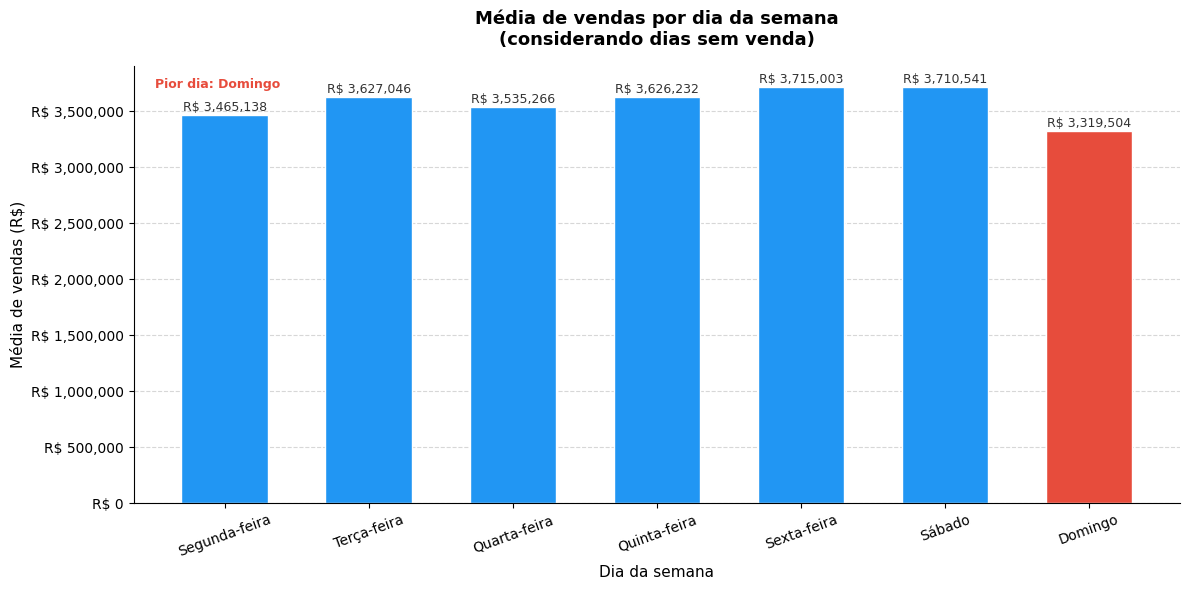

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

cores = ['#e74c3c' if v == df_media['media_com_zeros'].min() else '#2196F3'
         for v in df_media['media_com_zeros']]

bars = ax.bar(df_media['dia_semana'], df_media['media_com_zeros'], color=cores, edgecolor='white', width=0.6)

for bar, valor in zip(bars, df_media['media_com_zeros']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + df_media['media_com_zeros'].max() * 0.01,
        f"R$ {valor:,.0f}",
        ha='center', fontsize=9, color='#333333'
    )

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.set_xlabel('Dia da semana', fontsize=11)
ax.set_ylabel('Média de vendas (R$)', fontsize=11)
ax.set_title('Média de vendas por dia da semana\n(considerando dias sem venda)', fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.xticks(rotation=20)

# Legenda pior dia
pior_dia = df_media.loc[df_media['media_com_zeros'].idxmin(), 'dia_semana']
ax.annotate(f'Pior dia: {pior_dia}', xy=(0.02, 0.95), xycoords='axes fraction',
            fontsize=9, color='#e74c3c', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/reports/media_vendas_dia_semana.png', dpi=150, bbox_inches='tight')
plt.show()

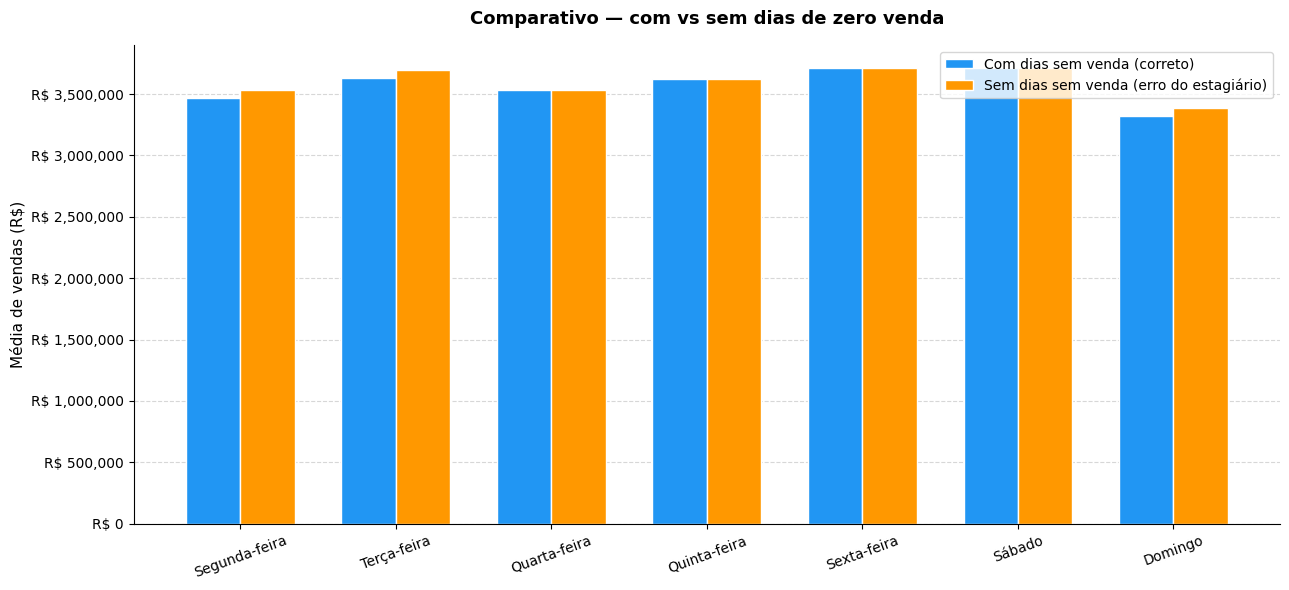

In [8]:
fig, ax = plt.subplots(figsize=(13, 6))

x = range(len(df_media))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], df_media['media_com_zeros'],
               width=width, label='Com dias sem venda (correto)', color='#2196F3', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], df_media['media_sem_zeros'],
               width=width, label='Sem dias sem venda (erro do estagiário)', color='#FF9800', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(df_media['dia_semana'], rotation=20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.set_ylabel('Média de vendas (R$)', fontsize=11)
ax.set_title('Comparativo — com vs sem dias de zero venda', fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../docs/reports/comparativo_media_vendas.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
print("Média de vendas por dia da semana")
print(f"\nPior dia da semana: {pior_dia}")
df_media[['dia_semana', 'media_com_zeros', 'media_sem_zeros']].round(2).sort_values(by="media_com_zeros")

Média de vendas por dia da semana

Pior dia da semana: Domingo


,dia_semana,media_com_zeros,media_sem_zeros
6,Domingo,3319503.57,3383959.95
0,Segunda-feira,3465137.71,3532421.94
2,Quarta-feira,3535265.63,3535265.63
3,Quinta-feira,3626232.44,3626232.44
1,Terça-feira,3627045.76,3697473.84
5,Sábado,3710540.55,3710540.55
4,Sexta-feira,3715003.41,3715003.41
